<a href="https://colab.research.google.com/github/PrathamLaddha/Lipophilicity_Prediction_NNs/blob/main/GAT_DMPNN_Lipophilicity_OPERA_cleaned_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GAT-DMPNN Lipophilicity Prediction — Cleaned & Improved Version

### What changed in this pass

**1. Dataset conflict cleanup (the main fix)**
- `MoleculeNet("lipo")` and the OPERA SDFs measure **two different physical quantities**: MoleculeNet's Lipophilicity target is experimental **logD at pH 7.4** (ChEMBL AZ dataset), while OPERA's `LogP` target is the neutral-species **octanol/water logP** (PHYSPROP-derived). For ionizable compounds `logD != logP`, so simply concatenating the two datasets (the old Cell 3) silently gave duplicate/near-duplicate molecules **two conflicting labels**. That's a real source of label noise.
- Some molecules are also physically duplicated *within* and *across* the two sources (same compound, different SMILES spelling/tautomer/salt form). The old scaffold split never de-duplicated anything, so the same molecule could land in both train and test — leakage that inflates R² without helping (or while hurting) MAE/RMSE.
- This notebook standardizes every molecule to a canonical structure + InChIKey, finds cross-source overlaps, keeps a single label where the two sources agree, and **drops** molecules where MoleculeNet and OPERA disagree by more than a tolerance (their target isn't reliably the same physical quantity there, so training on both values is just noise). Everything is reported so you can see exactly how many molecules were affected.

**2. Why R² went up while MAE/RMSE went down (before cleaning)**
- R² = 1 − SS_res/SS_tot. Adding OPERA massively widens the target range/variance (SS_tot grows a lot), so R² can rise even when *absolute* errors get worse from conflicting/noisy labels. MAE/RMSE don't have that scaling effect — they answer "how many log units off am I, on average / in the worst case", which is a more honest read on what OPERA integration actually did. This notebook keeps R² but adds metrics that aren't fooled by scale.

**3. Two concrete modeling fixes aimed at MAE/RMSE**
- Target (y) standardization was computed (`y_mean`, `y_std`) in the original notebook but never actually used — the model trained on raw LogD/LogP scale the whole time. It's now wired into training/eval (standardize -> train -> inverse-transform before scoring), which stabilizes optimization on what is now a wider, more heterogeneous target range.
- Loss swapped from plain `MSELoss` to `SmoothL1Loss` (Huber). MSE weights outliers quadratically — exactly what a still-imperfectly-clean, multi-source dataset will punish you for. Huber is a much closer proxy for MAE and is more robust to remaining label noise/outlier compounds.

**4. Metric additions**
Beyond MAE / RMSE / R², this notebook adds **Median Absolute Error** (robust to outliers), **Max Error** (worst case — matters if the model feeds into a regulatory/ADMET decision), **Pearson r** and **Spearman rho** (linear vs. rank correlation — divergence between them flags nonlinearity), **Explained Variance**, and **% of predictions within 0.5 / 1.0 log units** (the tolerance cheminformatics papers usually report LogP models against). A residual-vs-actual plot is added next to the parity plot to check for systematic bias at high/low LogP.


In [1]:
# -- Cell: Install dependencies --------------------------------------------
try:
    from torch_geometric.datasets import MoleculeNet
    from torch_geometric.loader import DataLoader
    from torch_geometric.nn import MessagePassing, global_add_pool
except ImportError:
    print("Installing torch_geometric...")
    import subprocess
    subprocess.run(["pip", "install", "torch_geometric"], check=True)

try:
    from rdkit import Chem
except ImportError:
    print("Installing rdkit...")
    import subprocess
    subprocess.run(["pip", "install", "rdkit"], check=True)

try:
    from scipy import stats
except ImportError:
    print("Installing scipy...")
    import subprocess
    subprocess.run(["pip", "install", "scipy"], check=True)

try:
    import pandas as pd
except ImportError:
    print("Installing pandas...")
    import subprocess
    subprocess.run(["pip", "install", "pandas"], check=True)

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Installing torch_geometric...
Installing rdkit...
PyTorch version: 2.11.0+cu128
CUDA available: True
Using device: cuda


In [2]:
# -- Cell: Featurizer (no duplicate structural features) -------------------
from torch_geometric.transforms import BaseTransform
from rdkit import Chem
from rdkit.Chem import Descriptors
import torch

class MolecularFeaturizer(BaseTransform):

    def forward(self, data):
        mol = Chem.MolFromSmiles(data.smiles)
        if mol is None:
            return data

        # Global molecular descriptors (same value broadcast to every atom for context)
        tpsa    = Descriptors.TPSA(mol) / 500.0
        f_csp3  = Descriptors.FractionCSP3(mol)

        new_x = []
        for i, atom in enumerate(mol.GetAtoms()):
            # Baseline features already in data.x (9 dims, PyG's from_smiles atom encoding)
            baseline = data.x[i].tolist()

            # New, non-redundant features only
            formal_charge = float(atom.GetFormalCharge())

            # Final: 9 baseline + 3 new = 12 features
            atom_features = baseline + [formal_charge, tpsa, f_csp3]
            new_x.append(atom_features)

        data.x = torch.tensor(new_x, dtype=torch.float)
        return data

featurizer = MolecularFeaturizer()


In [3]:
# -- Cell: Load raw MoleculeNet + OPERA (SMILES + target only) -------------
# We deliberately do NOT featurize into PyG graphs yet. We first want every
# molecule as a plain (smiles, y, source) record so we can standardize,
# de-duplicate and resolve source conflicts *before* paying the cost of
# graph featurization and before anything touches the scaffold split.

import torch
from rdkit import Chem
from torch_geometric.datasets import MoleculeNet
from tqdm import tqdm

print("Loading MoleculeNet Lipophilicity dataset (raw, no pre_transform)...")
lipo_raw = MoleculeNet(root='.', name='lipo', force_reload=True)

moleculenet_records = []  # list of dicts: smiles, y, source
for i in range(len(lipo_raw)):
    d = lipo_raw[i]
    smi = d.smiles
    y_val = float(d.y.view(-1)[0])
    moleculenet_records.append({"smiles": smi, "y": y_val, "source": "moleculenet_logD"})

print(f"MoleculeNet records: {len(moleculenet_records)}")

print("\nReading OPERA structure data files (.sdf)...")
suppl_train = Chem.SDMolSupplier('TR_LogP_10537.sdf')
suppl_val   = Chem.SDMolSupplier('TST_LogP_3513.sdf')
combined_sdf_molecules = list(suppl_train) + list(suppl_val)

opera_records = []
for mol in tqdm(combined_sdf_molecules):
    if mol is None:
        continue
    try:
        smi = Chem.MolToSmiles(mol)
        logp_val = float(mol.GetProp('LogP'))
        opera_records.append({"smiles": smi, "y": logp_val, "source": "opera_logP"})
    except Exception:
        continue

print(f"OPERA records parsed: {len(opera_records)}")


Loading MoleculeNet Lipophilicity dataset (raw, no pre_transform)...


Processing...
Done!


MoleculeNet records: 4200

Reading OPERA structure data files (.sdf)...


100%|██████████| 14050/14050 [00:01<00:00, 13130.52it/s]

OPERA records parsed: 14039


In [4]:
# -- Cell: Standardize, de-duplicate, resolve cross-source conflicts -------
from rdkit import Chem
from collections import defaultdict
import numpy as np

CONFLICT_TOLERANCE = 0.5   # log units; molecules that disagree by more than this
                            # between logD (MoleculeNet) and logP (OPERA) are treated
                            # as unreliable/ambiguous ground truth and dropped rather
                            # than guessed at.

def to_inchikey(smiles):
    """Canonical, representation-independent key for de-duplication.
    Returns None for anything RDKit can't parse (skip it)."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None, None
    canon_smiles = Chem.MolToSmiles(mol)
    try:
        key = Chem.MolToInchiKey(mol)
    except Exception:
        return None, None
    if not key:
        return None, None
    return key, canon_smiles

# 1. Key every record by InChIKey, grouping duplicates (within *and* across sources)
by_key = defaultdict(list)
n_unparseable = 0
for rec in moleculenet_records + opera_records:
    key, canon_smiles = to_inchikey(rec["smiles"])
    if key is None:
        n_unparseable += 1
        continue
    rec["canon_smiles"] = canon_smiles
    by_key[key].append(rec)

print(f"Unparseable / dropped structures: {n_unparseable}")
print(f"Unique molecules (by InChIKey) across both sources: {len(by_key)}")

# 2. Walk every InChIKey group and decide what to keep
clean_records = []
n_single_source = 0
n_agree_dedup   = 0
n_conflict_drop = 0
n_within_source_dup = 0

for key, group in by_key.items():
    sources_present = {r["source"] for r in group}

    if len(sources_present) == 1:
        # Only appears in one source. Still may be an internal duplicate
        # (e.g. same molecule listed twice within the OPERA SDF) -> collapse
        # to a single record; if internal duplicate values disagree a lot,
        # keep the median (robust to a single bad entry).
        if len(group) > 1:
            n_within_source_dup += 1
        vals = [r["y"] for r in group]
        y_final = float(np.median(vals)) if len(vals) > 1 else vals[0]
        rec = dict(group[0])
        rec["y"] = y_final
        clean_records.append(rec)
        n_single_source += 1
        continue

    # Molecule appears in BOTH MoleculeNet (logD) and OPERA (logP)
    y_moleculenet = [r["y"] for r in group if r["source"] == "moleculenet_logD"]
    y_opera       = [r["y"] for r in group if r["source"] == "opera_logP"]
    y_mn  = float(np.median(y_moleculenet))
    y_op  = float(np.median(y_opera))

    if abs(y_mn - y_op) <= CONFLICT_TOLERANCE:
        # logD ~= logP for this compound (likely non-ionizable / values agree)
        # -> safe to keep, use the MoleculeNet (curated benchmark) label as
        # the anchor value and drop the OPERA duplicate.
        rec = dict(group[0])
        rec["smiles"] = rec.get("canon_smiles", rec["smiles"])
        rec["y"] = y_mn
        rec["source"] = "moleculenet_logD"
        clean_records.append(rec)
        n_agree_dedup += 1
    else:
        # Conflicting ground truth for the same molecule -> drop entirely
        # rather than silently teach the model two different answers for
        # the same input graph.
        n_conflict_drop += 1

print("\n--- Cross-source cleaning report ---")
print(f"Kept, single-source molecules:                 {n_single_source}")
print(f"  (of which had internal duplicate entries):   {n_within_source_dup}")
print(f"Overlap molecules, sources agreed (kept, 1x):   {n_agree_dedup}")
print(f"Overlap molecules, sources conflicted (DROPPED): {n_conflict_drop}")
print(f"Final clean molecule count:                     {len(clean_records)}")


Unparseable / dropped structures: 0
Unique molecules (by InChIKey) across both sources: 17992

--- Cross-source cleaning report ---
Kept, single-source molecules:                 17753
  (of which had internal duplicate entries):   5
Overlap molecules, sources agreed (kept, 1x):   121
Overlap molecules, sources conflicted (DROPPED): 118
Final clean molecule count:                     17874


In [5]:
# -- Cell: Featurize the single, cleaned dataset ---------------------------
# Every remaining molecule (regardless of original source) now goes through
# the exact same path: from_smiles -> MolecularFeaturizer. This removes any
# chance of the two sources ending up on subtly different feature pipelines.

import torch
from torch_geometric.utils import from_smiles
from tqdm import tqdm

dataset = []
n_failed = 0
for rec in tqdm(clean_records):
    try:
        data = from_smiles(rec["smiles"])
        if data is None or data.x is None:
            n_failed += 1
            continue
        data.y = torch.tensor([[rec["y"]]], dtype=torch.float)
        data = featurizer(data)
        if data.x is None:
            n_failed += 1
            continue
        dataset.append(data)
    except Exception:
        n_failed += 1
        continue

print(f"Failed to featurize: {n_failed}")
print(f"\n--- Final Combined Dataset ---")
print(f"Total molecules:        {len(dataset)}")
print(f"Node feature dimension: {dataset[0].num_node_features}")  # should be 12
print(f"Edge feature dimension: {dataset[0].num_edge_features}")


100%|██████████| 17874/17874 [00:33<00:00, 530.18it/s]

Failed to featurize: 0

--- Final Combined Dataset ---
Total molecules:        17874
Node feature dimension: 12
Edge feature dimension: 3


In [6]:
# -- Cell: Bemis-Murcko Scaffold Split & DataLoader Initialization ---------
import torch
from torch_geometric.loader import DataLoader
from collections import defaultdict
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold

torch.manual_seed(42)
n = len(dataset)

print("Calculating molecular frameworks for Bemis-Murcko Scaffold Split...")
scaffolds = defaultdict(list)

# Every Data object now reliably has `.smiles` (set by from_smiles), since
# de-duplication happened before featurization -- no more guessing which
# attribute a given object might have.
for idx, data in enumerate(dataset):
    try:
        mol = Chem.MolFromSmiles(data.smiles)
        scaffold = MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=False)
    except Exception:
        scaffold = ""
    scaffolds[scaffold].append(idx)

scaffold_sets = sorted(list(scaffolds.values()), key=len, reverse=True)

train_idx, val_idx, test_idx = [], [], []
n_train = int(0.8 * n)
n_val   = int(0.1 * n)

for scaffold_set in scaffold_sets:
    if len(train_idx) + len(scaffold_set) <= n_train:
        train_idx.extend(scaffold_set)
    elif len(train_idx) + len(val_idx) + len(scaffold_set) <= n_train + n_val:
        val_idx.extend(scaffold_set)
    else:
        test_idx.extend(scaffold_set)

train_loader = DataLoader([dataset[i] for i in train_idx], batch_size=32, shuffle=True)
val_loader   = DataLoader([dataset[i] for i in val_idx],   batch_size=32, shuffle=False)
test_loader  = DataLoader([dataset[i] for i in test_idx],  batch_size=32, shuffle=False)

print(f"\nScaffold Split Complete:")
print(f"Train: {len(train_idx)} ({len(train_idx)/n:.1%}) | "
      f"Val: {len(val_idx)} ({len(val_idx)/n:.1%}) | "
      f"Test: {len(test_idx)} ({len(test_idx)/n:.1%})")


Calculating molecular frameworks for Bemis-Murcko Scaffold Split...

Scaffold Split Complete:
Train: 14299 (80.0%) | Val: 1787 (10.0%) | Test: 1788 (10.0%)


In [7]:
# -- Cell: Target standardization (computed AND used) -----------------------
# Previously y_mean/y_std were computed here but never referenced again --
# the model trained on raw log-units the whole time. Now that OPERA widens
# the target range considerably, standardizing gives the optimizer a much
# better-conditioned target and is used consistently in train/eval below.
import numpy as np

train_y_vals = np.array([dataset[i].y.item() for i in train_idx])

y_mean = float(np.mean(train_y_vals))
y_std  = float(np.std(train_y_vals))

y_mean_t = torch.tensor(y_mean, dtype=torch.float)
y_std_t  = torch.tensor(y_std, dtype=torch.float)

print(f"Training Targets -> Mean: {y_mean:.4f} | Std: {y_std:.4f}")

def standardize(y):
    return (y - y_mean_t.to(y.device)) / y_std_t.to(y.device)

def destandardize(y):
    return y * y_std_t.to(y.device) + y_mean_t.to(y.device)


Training Targets -> Mean: 2.0536 | Std: 1.7390


In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import MessagePassing

class DMPNNConv(MessagePassing):
    def __init__(self, hidden_dim):
        super().__init__(aggr='add', flow='source_to_target')
        self.lin = nn.Linear(hidden_dim, hidden_dim)
        self.bn  = nn.BatchNorm1d(hidden_dim)

    def forward(self, x, edge_index, edge_attr):
        # Propagate: message() combines atom + bond features
        out = self.propagate(edge_index, x=x, edge_attr=edge_attr)
        return F.relu(self.bn(out))

    def message(self, x_j, edge_attr):
        # x_j: source atom features | edge_attr: bond features
        return self.lin(x_j + edge_attr)


In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATv2Conv, global_add_pool

class MolecularGraphEncoder(nn.Module):
    def __init__(self, num_node_features, num_edge_features, hidden_dim):
        super().__init__()

        # Embed raw features into hidden space
        self.node_emb = nn.Linear(num_node_features, hidden_dim)
        self.edge_emb = nn.Linear(num_edge_features, hidden_dim)

        # DMPNN layer wired in as the first message passing step
        self.dmpnn = DMPNNConv(hidden_dim)
        self.ln0   = nn.LayerNorm(hidden_dim)

        # GAT layers for attention-based aggregation
        self.conv1 = GATv2Conv(hidden_dim, hidden_dim // 2, heads=2, edge_dim=hidden_dim, dropout=0.1)
        self.ln1   = nn.LayerNorm(hidden_dim)

        self.conv2 = GATv2Conv(hidden_dim, hidden_dim // 2, heads=2, edge_dim=hidden_dim, dropout=0.1)
        self.ln2   = nn.LayerNorm(hidden_dim)

        # Virtual node MLP: lets global graph state inform local node updates
        self.virtual_node_mlp = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

    def forward(self, data):
        x         = data.x.float()
        edge_index= data.edge_index
        edge_attr = data.edge_attr
        batch     = data.batch

        # Handle 1D edge attributes (scalar bond types)
        if edge_attr.dim() == 1:
            edge_attr = edge_attr.unsqueeze(-1)
        edge_attr = edge_attr.float()

        # 1. Embed into hidden space
        x = F.relu(self.node_emb(x))
        edge_attr = F.relu(self.edge_emb(edge_attr))

        # 2. DMPNN: edge-aware directed message passing
        x = self.ln0(x + self.dmpnn(x, edge_index, edge_attr))  # residual

        # 3. GATv2 layer 1
        x = self.ln1(self.conv1(x, edge_index, edge_attr))
        x = F.relu(x)

        # 4. GATv2 layer 2
        x = self.ln2(self.conv2(x, edge_index, edge_attr))
        x = F.relu(x)

        # 5. Global pooling + virtual node refinement
        graph_emb = global_add_pool(x, batch)
        graph_emb = graph_emb + self.virtual_node_mlp(graph_emb)

        return x, graph_emb


In [10]:
import torch.nn as nn
import torch.nn.functional as F

class LipophilicityDMPNN(nn.Module):
    def __init__(self, encoder, hidden_dim):
        super().__init__()
        self.encoder  = encoder
        self.fc1      = nn.Linear(hidden_dim, hidden_dim // 2)
        self.dropout  = nn.Dropout(0.2)
        self.fc2      = nn.Linear(hidden_dim // 2, 1)

    def forward(self, data):
        _, graph_emb = self.encoder(data)
        x = F.relu(self.fc1(graph_emb))
        x = self.dropout(x)
        return self.fc2(x)


input_dim = dataset[0].num_node_features    # 12
edge_dim  = dataset[0].num_edge_features
HIDDEN    = 128

encoder = MolecularGraphEncoder(
    num_node_features=input_dim,
    num_edge_features=edge_dim,
    hidden_dim=HIDDEN
)
model = LipophilicityDMPNN(encoder, hidden_dim=HIDDEN).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10)

# CHANGED: SmoothL1Loss's `beta` sets where it switches from quadratic (MSE-like)
# to linear (MAE-like) behavior. With standardized targets, an error of "1.0"
# means "a full standard deviation off" -- a huge miss, not a mild outlier -- so
# the default beta=1.0 almost never engages the robust/linear region and the
# loss ends up behaving like plain (scaled) MSE again. Lowering beta makes the
# loss actually switch to linear behavior for realistic-sized residuals, so it
# behaves the way it was intended to: robust to the outlier compounds, closer
# to optimizing MAE directly. Tune this -- 0.25-0.5 is a reasonable starting
# range on standardized targets; raise it if training becomes unstable.
HUBER_BETA = 0.3
criterion = nn.SmoothL1Loss(beta=HUBER_BETA)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model ready | input_dim={input_dim} | edge_dim={edge_dim} | params={total_params:,}")
print(f"Huber beta: {HUBER_BETA}")


Model ready | input_dim=12 | edge_dim=3 | params=160,385
Huber beta: 0.3


In [11]:
# -- Cell: Train / Validate helpers ------------------------------------------
# train_epoch / eval_epoch operate on the standardized target (what the loss
# is actually computed on). eval_mae is new: it de-standardizes predictions
# back to real LogD/LogP units and reports plain MAE, which is what we
# actually want to select checkpoints on (see next cell) rather than the
# standardized-scale training loss.

from sklearn.metrics import mean_absolute_error

def train_epoch():
    model.train()
    total_loss = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        pred = model(data).view(-1)
        target = standardize(data.y.view(-1))
        loss = criterion(pred, target)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)


@torch.no_grad()
def eval_epoch(loader):
    """Standardized-scale loss -- used for the LR scheduler (relative
    improvement is all that matters there, so the scale doesn't matter)."""
    model.eval()
    total_loss = 0
    for data in loader:
        data = data.to(device)
        pred = model(data).view(-1)
        target = standardize(data.y.view(-1))
        total_loss += criterion(pred, target).item()
    return total_loss / len(loader)


@torch.no_grad()
def eval_mae(loader):
    """Real-unit (LogD/LogP) MAE -- used for checkpointing, since that's the
    metric we actually care about improving, and it's not guaranteed to rank
    checkpoints the same way the standardized training loss does."""
    model.eval()
    preds, targets = [], []
    for data in loader:
        data = data.to(device)
        pred = destandardize(model(data).view(-1)).cpu().numpy()
        tgt  = data.y.view(-1).cpu().numpy()
        preds.append(pred)
        targets.append(tgt)
    preds = np.concatenate(preds)
    targets = np.concatenate(targets)
    return mean_absolute_error(targets, preds)


In [12]:
NUM_EPOCHS    = 150
PATIENCE      = 40     # stop if val MAE doesn't improve for 40 epochs
best_val_mae  = float('inf')
patience_ctr  = 0

train_losses, val_losses, val_maes = [], [], []

print("Starting training...\n")
for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_epoch()
    val_loss   = eval_epoch(val_loader)          # standardized Huber, for the scheduler
    val_mae    = eval_mae(val_loader)             # real-unit MAE, for checkpointing

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_maes.append(val_mae)

    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | Train Huber (std.): {train_loss:.4f} | "
              f"Val Huber (std.): {val_loss:.4f} | Val MAE (real units): {val_mae:.4f}")

    # CHANGED: checkpoint on validation MAE in real units, not on the
    # standardized-scale training loss. The two aren't guaranteed to agree on
    # which epoch is "best", and MAE is the metric we actually report/care about.
    if val_mae < best_val_mae:
        best_val_mae = val_mae
        patience_ctr = 0
        torch.save(model.state_dict(), "best_model.pt")
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch} (best val MAE: {best_val_mae:.4f})")
            break

print("\nTraining complete.")


Starting training...

Epoch 010 | Train Huber (std.): 0.2230 | Val Huber (std.): 0.3313 | Val MAE (real units): 0.7959
Epoch 020 | Train Huber (std.): 0.1655 | Val Huber (std.): 0.3049 | Val MAE (real units): 0.7464
Epoch 030 | Train Huber (std.): 0.1396 | Val Huber (std.): 0.2892 | Val MAE (real units): 0.7179
Epoch 040 | Train Huber (std.): 0.1256 | Val Huber (std.): 0.2511 | Val MAE (real units): 0.6485
Epoch 050 | Train Huber (std.): 0.1178 | Val Huber (std.): 0.2377 | Val MAE (real units): 0.6216
Epoch 060 | Train Huber (std.): 0.0962 | Val Huber (std.): 0.2216 | Val MAE (real units): 0.5904
Epoch 070 | Train Huber (std.): 0.0919 | Val Huber (std.): 0.2227 | Val MAE (real units): 0.5913
Epoch 080 | Train Huber (std.): 0.0796 | Val Huber (std.): 0.2074 | Val MAE (real units): 0.5603
Epoch 090 | Train Huber (std.): 0.0745 | Val Huber (std.): 0.2077 | Val MAE (real units): 0.5607
Epoch 100 | Train Huber (std.): 0.0707 | Val Huber (std.): 0.2136 | Val MAE (real units): 0.5732
Epoch 11

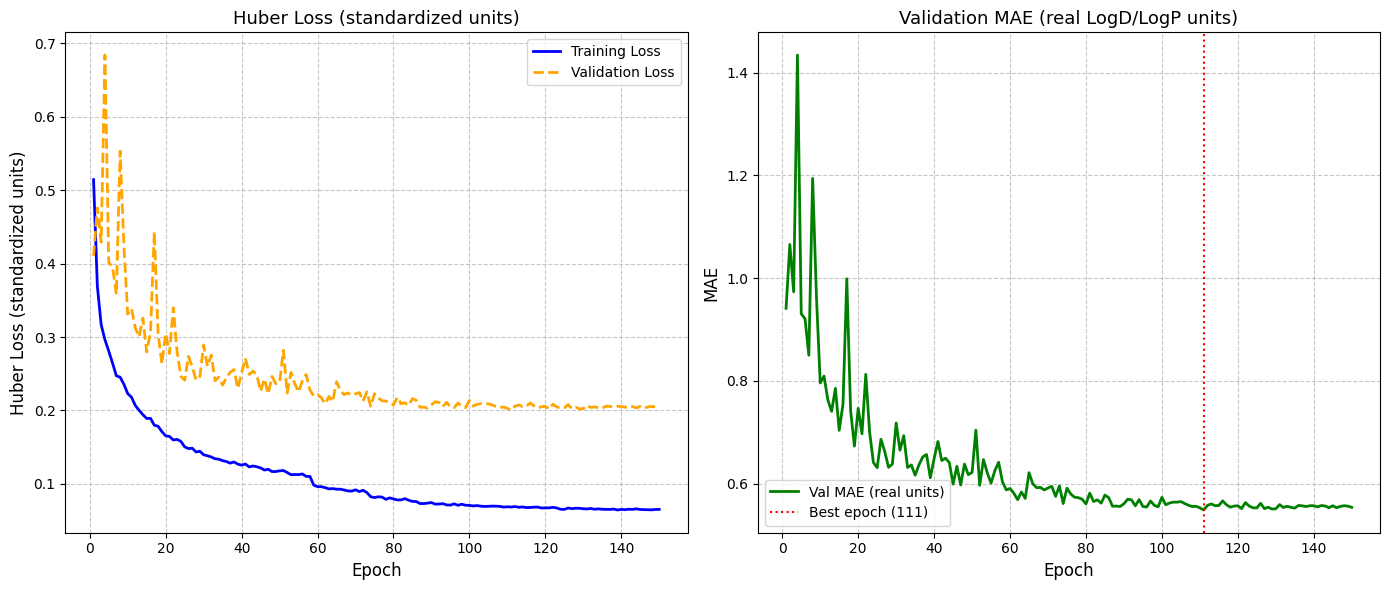

Best validation MAE (real units, used for checkpointing): 0.5485


In [13]:
# -- Cell: Loss curves (train + val Huber, and val MAE) ---------------------
import matplotlib.pyplot as plt

epochs_ran = len(train_losses)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.plot(range(1, epochs_ran + 1), train_losses, label='Training Loss',   color='blue',  linewidth=2)
ax.plot(range(1, epochs_ran + 1), val_losses,   label='Validation Loss', color='orange', linewidth=2, linestyle='--')
ax.set_title('Huber Loss (standardized units)', fontsize=13)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Huber Loss (standardized units)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.7)
ax.legend(fontsize=10)

# This is the curve checkpointing actually watches now -- worth seeing on its
# own scale (real log units), since it doesn't necessarily track the Huber
# curve on the left epoch-for-epoch.
ax2 = axes[1]
ax2.plot(range(1, epochs_ran + 1), val_maes, label='Val MAE (real units)', color='green', linewidth=2)
best_epoch = int(np.argmin(val_maes)) + 1
ax2.axvline(best_epoch, color='red', linestyle=':', linewidth=1.5, label=f'Best epoch ({best_epoch})')
ax2.set_title('Validation MAE (real LogD/LogP units)', fontsize=13)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('MAE', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig('loss_curve_fixed.png', dpi=150)
plt.show()
print(f"Best validation MAE (real units, used for checkpointing): {best_val_mae:.4f}")


In [14]:
# -- Cell: Test set evaluation -- expanded metric suite ---------------------
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    median_absolute_error, max_error, explained_variance_score
)
from scipy.stats import pearsonr, spearmanr
import numpy as np

model.load_state_dict(torch.load("best_model.pt", map_location=device))
model.eval()

all_preds, all_targets = [], []
with torch.no_grad():
    for data in test_loader:
        data = data.to(device)
        pred_std = model(data).view(-1)
        pred = destandardize(pred_std).cpu().numpy()   # back to real LogD/LogP units
        tgt  = data.y.view(-1).cpu().numpy()
        all_preds.append(pred)
        all_targets.append(tgt)

all_preds   = np.concatenate(all_preds)
all_targets = np.concatenate(all_targets)
residuals   = all_preds - all_targets
abs_err     = np.abs(residuals)

mae   = mean_absolute_error(all_targets, all_preds)
rmse  = np.sqrt(mean_squared_error(all_targets, all_preds))
r2    = r2_score(all_targets, all_preds)
medae = median_absolute_error(all_targets, all_preds)
maxerr = max_error(all_targets, all_preds)
evs   = explained_variance_score(all_targets, all_preds)
pearson_r, _  = pearsonr(all_targets, all_preds)
spearman_rho, _ = spearmanr(all_targets, all_preds)
pct_within_05 = float(np.mean(abs_err <= 0.5) * 100)
pct_within_10 = float(np.mean(abs_err <= 1.0) * 100)

print("\n--- TEST SET RESULTS ---")
print(f"MAE:                 {mae:.4f}  (average error, log units)")
print(f"RMSE:                {rmse:.4f}  (penalizes large errors more)")
print(f"Median Abs. Error:   {medae:.4f}  (robust to outlier compounds)")
print(f"Max Error:           {maxerr:.4f}  (worst single prediction)")
print(f"R^2:                 {r2:.4f}  (fraction of variance explained)")
print(f"Explained Variance:  {evs:.4f}  (like R^2, ignores any constant bias)")
print(f"Pearson r:           {pearson_r:.4f}  (linear correlation)")
print(f"Spearman rho:        {spearman_rho:.4f}  (rank correlation)")
print(f"  -> Pearson vs Spearman gap of {abs(pearson_r - spearman_rho):.3f} suggests "
      f"{'some nonlinearity/outlier influence' if abs(pearson_r - spearman_rho) > 0.03 else 'a mostly linear fit'}")
print(f"Within +/-0.5 log units: {pct_within_05:.1f}% of test molecules")
print(f"Within +/-1.0 log units: {pct_within_10:.1f}% of test molecules")



--- TEST SET RESULTS ---
MAE:                 0.5005  (average error, log units)
RMSE:                0.7442  (penalizes large errors more)
Median Abs. Error:   0.3555  (robust to outlier compounds)
Max Error:           7.7200  (worst single prediction)
R^2:                 0.8315  (fraction of variance explained)
Explained Variance:  0.8331  (like R^2, ignores any constant bias)
Pearson r:           0.9128  (linear correlation)
Spearman rho:        0.9033  (rank correlation)
  -> Pearson vs Spearman gap of 0.009 suggests a mostly linear fit
Within +/-0.5 log units: 64.3% of test molecules
Within +/-1.0 log units: 88.5% of test molecules


In [15]:
# -- Cell: Inspect the worst test-set predictions ---------------------------
# Max Error alone just tells you a number; this shows you *which* molecule(s)
# are responsible, so you can check whether it's a featurization edge case,
# a compound that shouldn't have survived the cleaning step, or a genuinely
# hard structure the model just hasn't learned well.

import pandas as pd

test_smiles = [dataset[i].smiles for i in test_idx]

results_df = pd.DataFrame({
    "smiles": test_smiles,
    "actual": all_targets,
    "predicted": all_preds,
    "abs_error": abs_err,
})

top_errors = results_df.sort_values("abs_error", ascending=False).head(15)
print("Top 15 worst test-set predictions:\n")
print(top_errors.to_string(index=False))


Top 15 worst test-set predictions:

                                                                      smiles  actual  predicted  abs_error
          C[Si]1(C)O[Si](C)(C)O[Si](C)(C)O[Si](C)(C)O[Si](C)(C)O[Si](C)(C)O1    9.06   1.339954   7.720046
                     C[Si]1(C)O[Si](C)(C)O[Si](C)(C)O[Si](C)(C)O[Si](C)(C)O1    8.03   1.145246   6.884754
                                C[Si]1(C)O[Si](C)(C)O[Si](C)(C)O[Si](C)(C)O1    6.74   0.929018   5.810981
[H]/N=C(\N/C(=N/[H])NCCCCCCN/C(=N\[H])N/C(=N\[H])Nc1ccc(Cl)cc1)Nc1ccc(Cl)cc1    0.08   3.814576   3.734576
                      CCCCCCCN(CCc1ccc(OC(C)(C)C(=O)O)cc1)C(=O)Nc2ccc(F)cc2F    1.93   5.624901   3.694901
                                     CC(C)(C)c1ccc(cc1)C2=NC(=O)C(CC(=O)O)S2   -0.10   3.545321   3.645320
         CC1(C)CNC(=NN=C(/C=C/c2ccc(C(F)(F)F)cc2)/C=C/c2ccc(C(F)(F)F)cc2)NC1    2.31   5.887105   3.577105
                              COc1ccc2c(c1)c(CC(=O)O)c(C)n2C(=O)c1ccc(Cl)cc1    4.27   0.974611   3.295389
 

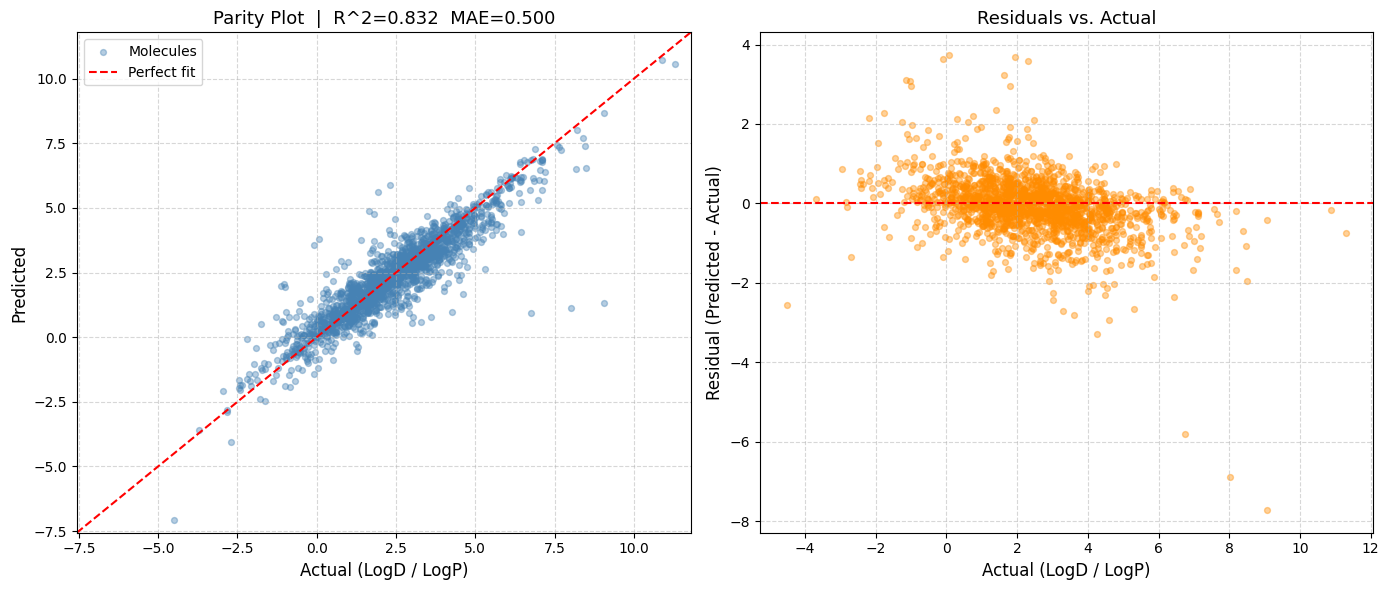

In [16]:
# -- Cell: Parity plot + residual plot --------------------------------------
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Parity plot
ax = axes[0]
ax.scatter(all_targets, all_preds, alpha=0.4, s=18, color='steelblue', label='Molecules')
lo = min(all_targets.min(), all_preds.min()) - 0.5
hi = max(all_targets.max(), all_preds.max()) + 0.5
ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1.5, label='Perfect fit')
ax.set_xlabel('Actual (LogD / LogP)', fontsize=12)
ax.set_ylabel('Predicted', fontsize=12)
ax.set_title(f'Parity Plot  |  R^2={r2:.3f}  MAE={mae:.3f}', fontsize=13)
ax.legend(fontsize=10)
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.grid(True, linestyle='--', alpha=0.5)

# Residual plot -- flags systematic bias at high/low ends of the range
ax2 = axes[1]
ax2.scatter(all_targets, residuals, alpha=0.4, s=18, color='darkorange')
ax2.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax2.set_xlabel('Actual (LogD / LogP)', fontsize=12)
ax2.set_ylabel('Residual (Predicted - Actual)', fontsize=12)
ax2.set_title('Residuals vs. Actual', fontsize=13)
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('parity_and_residual_plot.png', dpi=150)
plt.show()


## Optional: multi-seed comparison

A single run isn't enough to say whether one configuration (loss, `beta`, standardization on/off)
is actually better than another -- random init, dropout masks, and loader shuffling alone can move
test MAE by several hundredths. The cell below retrains from scratch across a few seeds for a given
`HUBER_BETA` and reports the mean +/- std of test MAE, so you can compare configurations properly
instead of off a single number. It reuses the model/encoder classes already defined above; it does
not touch `model`/`optimizer`/`best_model.pt` from the main run above.


In [17]:
# -- Optional: multi-seed A/B runner ----------------------------------------
# Retrains from scratch `N_SEEDS` times for a given HUBER_BETA and reports
# mean +/- std test MAE, so a configuration change can be judged on more than
# one run. Takes ~N_SEEDS x (one full training run), so only run this when
# you actually want to compare configurations, not on every notebook run.

N_SEEDS = 3
BETAS_TO_COMPARE = [0.3]   # e.g. [0.3, 1.0] to compare against the default beta

def run_once(seed, huber_beta, max_epochs=150, patience=40):
    torch.manual_seed(seed)

    enc = MolecularGraphEncoder(num_node_features=input_dim,
                                 num_edge_features=edge_dim,
                                 hidden_dim=HIDDEN)
    mdl = LipophilicityDMPNN(enc, hidden_dim=HIDDEN).to(device)
    opt = torch.optim.Adam(mdl.parameters(), lr=1e-3, weight_decay=1e-5)
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=10)
    crit = nn.SmoothL1Loss(beta=huber_beta)

    best_mae, patience_ctr = float('inf'), 0
    best_state = None

    for epoch in range(1, max_epochs + 1):
        mdl.train()
        for data in train_loader:
            data = data.to(device)
            opt.zero_grad()
            pred = mdl(data).view(-1)
            target = standardize(data.y.view(-1))
            loss = crit(pred, target)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(mdl.parameters(), max_norm=1.0)
            opt.step()

        mdl.eval()
        with torch.no_grad():
            val_loss_total = 0
            val_preds, val_targets = [], []
            for data in val_loader:
                data = data.to(device)
                pred_std = mdl(data).view(-1)
                val_loss_total += crit(pred_std, standardize(data.y.view(-1))).item()
                val_preds.append(destandardize(pred_std).cpu().numpy())
                val_targets.append(data.y.view(-1).cpu().numpy())
            val_loss = val_loss_total / len(val_loader)
            val_mae = mean_absolute_error(np.concatenate(val_targets), np.concatenate(val_preds))

        sch.step(val_loss)

        if val_mae < best_mae:
            best_mae, patience_ctr = val_mae, 0
            best_state = {k: v.clone() for k, v in mdl.state_dict().items()}
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                break

    mdl.load_state_dict(best_state)
    mdl.eval()
    with torch.no_grad():
        preds, targets = [], []
        for data in test_loader:
            data = data.to(device)
            preds.append(destandardize(mdl(data).view(-1)).cpu().numpy())
            targets.append(data.y.view(-1).cpu().numpy())
    return mean_absolute_error(np.concatenate(targets), np.concatenate(preds))

for beta in BETAS_TO_COMPARE:
    seed_maes = [run_once(seed=100 + s, huber_beta=beta) for s in range(N_SEEDS)]
    print(f"beta={beta}: test MAE per seed = {[round(m, 4) for m in seed_maes]} "
          f"| mean={np.mean(seed_maes):.4f} +/- {np.std(seed_maes):.4f}")


KeyboardInterrupt: 